In [32]:
import numpy as np
import matplotlib.pyplot as plt
from planar_utils import plot_decision_boundary, sigmoid, load_planar_dataset

In [33]:
X, Y = load_planar_dataset()

In [23]:
def layer_sizes(X, Y):
    n_x = X.shape[0]
    n_h = 4 
    n_y = Y.shape[0]
    
    return (n_x, n_h, n_y)

In [34]:
def initialize_parameters(n_x, n_h, n_y):
    W1 = np.random.randn(n_h, n_x) * 0.01
    b1 = np.zeros((n_h, 1))
    W2 = np.random.randn(n_y, n_h) * 0.01
    b2 = np.zeros((n_y, 1))
    
    parameters = {"W1": W1,
                  "b1": b1,
                  "W2": W2,
                  "b2": b2} 
    
    return parameters

In [35]:
def forward_propagation(X, parameters):
    W1 = parameters["W1"]
    b1 = parameters["b1"]
    W2 = parameters["W2"]
    b2 = parameters["b2"]
    
    Z1 = np.dot(W1, X) + b1
    A1 = np.tanh(Z1)
    Z2 = np.dot(W2, A1) + b2
    A2 = sigmoid(Z2)
    
    cache = {"Z1": Z1,
             "A1": A1,
             "Z2": Z2,
             "A2": A2}
    
    return A2, cache

In [36]:
def compute_cost(A2, Y): 
    m = Y.shape[1]

    logprobs = np.multiply(np.log(A2), Y) + (1 - Y) * np.log(1 - A2)
    cost = -1/m * np.sum(logprobs)
 
    cost = float(np.squeeze(cost))  
    
    return cost

In [37]:
def backward_propagation(parameters, cache, X, Y):
    m = X.shape[1]

    W1 = parameters["W1"]
    W2 = parameters["W2"]

    A1 = cache["A1"]
    A2 = cache["A2"]

    dZ2 = A2 - Y
    dW2 = 1/m * np.dot(dZ2, A1.T)
    db2 = 1/m * np.sum(dZ2, axis = 1, keepdims = True)
    dZ1 = np.dot(W2.T, dZ2) * (1 - np.power(A1, 2))
    dW1 = 1/m * np.dot(dZ1, X.T)
    db1 = 1/m * np.sum(dZ1, axis = 1, keepdims = True)

    grads = {"dW1": dW1,
             "db1": db1,
             "dW2": dW2,
             "db2": db2}
    
    return grads

In [38]:
def update_parameters(parameters, grads, learning_rate = 1.2):

    W1 = copy.deepcopy(parameters["W1"])
    b1 = parameters["b1"]
    W2 = copy.deepcopy(parameters["W2"])
    b2 = parameters["b2"]

    dW1 = grads["dW1"]
    db1 = grads["db1"]
    dW2 = grads["dW2"]
    db2 = grads["db2"]

    W1 = W1 - (learning_rate * dW1)
    b1 = b1 - (learning_rate * db1)
    W2 = W2 - (learning_rate * dW2)
    b2 = b2 - (learning_rate * db2)

    parameters = {"W1": W1,
                  "b1": b1,
                  "W2": W2,
                  "b2": b2}
    
    return parameters

In [39]:
def nn_model(X, Y, n_h, num_iterations = 10000, print_cost=False):

    n_x = layer_sizes(X, Y)[0]
    n_y = layer_sizes(X, Y)[2]
    
    parameters = initialize_parameters(n_x, n_h, n_y)

    for i in range(0, num_iterations):
        A2, cache = forward_propagation(X, parameters)
        cost = compute_cost(A2, Y)
        grads = backward_propagation(parameters, cache, X, Y)
        parameters = update_parameters(parameters, grads)
 
        if print_cost and i % 1000 == 0:
            print ("Cost after iteration %i: %f" %(i, cost))

    return parameters

In [40]:
def predict(parameters, X):
    A2, cache = forward_propagation(X, parameters)
    predictions = (A2 > 0.5)
    
    return predictions

Cost after iteration 0: 0.693161
Cost after iteration 1000: 0.281323
Cost after iteration 2000: 0.268958
Cost after iteration 3000: 0.261973
Cost after iteration 4000: 0.257413
Cost after iteration 5000: 0.254265
Cost after iteration 6000: 0.251988
Cost after iteration 7000: 0.250276
Cost after iteration 8000: 0.248949
Cost after iteration 9000: 0.247892
Accuracy: 91.25%


Text(0.5, 1.0, 'Decision Boundary for hidden layer size 4')

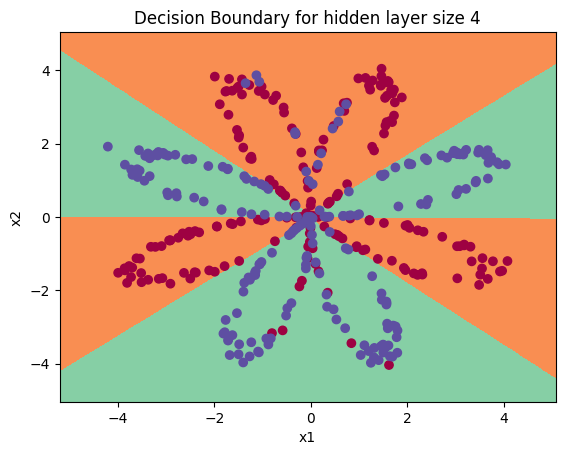

In [45]:
parameters = nn_model(X, Y, n_h = 4, num_iterations = 10000, print_cost=True)

predictions = predict(parameters, X)
accuracy = float(np.mean(predictions == Y) * 100)
print(f"Accuracy: {accuracy:.2f}%")

plot_decision_boundary(lambda x: predict(parameters, x.T), X, Y)
plt.title("Decision Boundary for hidden layer size " + str(4))